# IEA - SISEPUEDE Energy Crosswalk — Comparison Notebook

This notebook is a **walkthrough** of `sisepuede/calibration/iea_crosswalk.py`.
All the real logic lives in that module; here we just call it step-by-step
so you can see what each piece does.

**Steps:**
1. Setup — imports, paths
2. Run SISEPUEDE energy model
3. Build an `IEACrosswalk` object (loads the mapping CSV)
4. Aggregate SISEPUEDE outputs using the crosswalk
5. Load and normalise IEA data
6. Build the comparison table
7. Summarise and visualise

---
## 1. Setup

We import the SISEPUEDE file structure (gives us model attributes and
the path to the ref directory) and our new `IEACrosswalk` class.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
# Add the sisepuede repo root so local edits take precedence over the installed package
path = "/Users/dianamendez/sisepuede"
if path not in sys.path:
    sys.path.insert(0, path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
from sisepuede.calibration.iea_crosswalk        import IEACrosswalk
from sisepuede.calibration.iea_data_loader      import IEADataLoader

# ── Paths — change these ─────────────────────────────────────────────────────
PATH_SISEPUEDE_INPUT = "/Users/dianamendez/Documents/sisepuede/sisepuede_raw_inputs_latest_LBY_modified_march_2026.csv"
PATH_IEA_DATA_DIR    = "/Users/dianamendez/data_collection_temporary"  # root of IEA CSV repo
ISO_COUNTRY          = "LBY"
START_YEAR           = 2015 # year from where to start comparison
TRUE_DATA_LIMIT_YEAR = 2023 # last year of true data. the rest are projections
PATH_CROSSWALK_FILE  = "/Users/dianamendez/sisepuede/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv"
# ─────────────────────────────────────────────────────────────────────────────
# Run this notebook with the sisepuede-env kernel:
#   /Users/dianamendez/sisepuede-env/bin/python

file_struct      = SISEPUEDEFileStructure()
model_attributes = file_struct.model_attributes

---
## 2. Run SISEPUEDE — get energy outputs

`EnergyConsumption` depends on `AFOLU` and `IPPU`, so we run those first and merge their outputs in before calling the energy model.

In [2]:
from sisepuede.models.afolu              import AFOLU
from sisepuede.models.energy_consumption import EnergyConsumption
from sisepuede.models.ippu               import IPPU

model_afolu     = AFOLU            (model_attributes)
model_ippu      = IPPU             (model_attributes)
model_energycon = EnergyConsumption(model_attributes)

df_input = pd.read_csv(PATH_SISEPUEDE_INPUT)

# Only use truth available data for comparison
true_data_condition = df_input["year"] <= TRUE_DATA_LIMIT_YEAR
df_input = df_input.loc[true_data_condition]
print(f"Input shape: {df_input.shape}")
display(df_input)

# Run dependency models first, then merge their outputs as additional inputs
df_out_afolu = model_afolu(df_input)
df_out_ippu  = model_ippu (df_input)

df_input_energy = df_input.merge(df_out_afolu, how="left").merge(df_out_ippu, how="left")
df_out_energycon = model_energycon(df_input_energy)

print(f"Output shape: {df_out_energycon.shape}")
display(df_out_energycon)

Input shape: (9, 2420)


,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3,population_gnrl_rural,population_gnrl_urban,gdp_mmm_usd
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,795843.0,5735976.0,116.940831
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,808058.0,5824068.0,112.487607
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,821006.0,5917764.0,121.473195
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,834319.0,6014736.0,129.305468
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,846496.0,6104537.0,112.565781
5,2020,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,857578.0,6187821.0,77.180930
6,2021,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,867887.0,6267288.0,90.199384
7,2022,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,877793.0,6346012.0,88.610007
8,2023,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,886562.0,6419097.0,101.162039


Output shape: (9, 480)


,time_period,dem_trde_freight_mt_km,dem_trde_private_and_public_passenger_km,dem_trde_regional_passenger_km,emission_co2e_ch4_ccsq_direct_air_capture,emission_co2e_ch4_inen_agriculture_and_livestock,emission_co2e_ch4_inen_cement,emission_co2e_ch4_inen_chemicals,emission_co2e_ch4_inen_electronics,emission_co2e_ch4_inen_glass,...,vehicle_distance_traveled_trns_road_light_diesel,vehicle_distance_traveled_trns_road_light_electricity,vehicle_distance_traveled_trns_road_light_gasoline,vehicle_distance_traveled_trns_road_light_hydrocarbon_gas_liquids,vehicle_distance_traveled_trns_road_light_hydrogen,vehicle_distance_traveled_trns_water_borne,vehicle_distance_traveled_trns_water_borne_diesel,vehicle_distance_traveled_trns_water_borne_electricity,vehicle_distance_traveled_trns_water_borne_hydrogen,vehicle_distance_traveled_trns_water_borne_natural_gas
0,0,243207.015073,8.229379e+10,7.208654e+09,0.0,0.005427,0.000594,0.001823,0.000003,0.000396,...,9.634908e+09,3.757308e+08,1.236291e+10,0.0,0.0,4.868815e+06,4.868815e+06,0.0,0.0,0.0
1,1,235797.760528,8.003948e+10,7.011184e+09,0.0,0.005500,0.000604,0.001718,0.000003,0.000403,...,9.349937e+09,3.641232e+08,1.205135e+10,0.0,0.0,4.759688e+06,4.759688e+06,0.0,0.0,0.0
2,2,250866.311483,8.541177e+10,7.481779e+09,0.0,0.010420,0.000603,0.001695,0.000003,0.000402,...,9.956474e+09,3.872135e+08,1.288730e+10,0.0,0.0,5.050586e+06,5.050586e+06,0.0,0.0,0.0
3,3,263806.473089,9.009704e+10,7.892192e+09,0.0,0.013650,0.000607,0.001738,0.000003,0.000405,...,1.048110e+10,4.070839e+08,1.362173e+10,0.0,0.0,5.352734e+06,5.352734e+06,0.0,0.0,0.0
4,4,236484.888598,8.103428e+10,7.098325e+09,0.0,0.014537,0.000619,0.001807,0.000003,0.000413,...,9.407156e+09,3.649396e+08,1.227638e+10,0.0,0.0,4.828262e+06,4.828262e+06,0.0,0.0,0.0
5,5,177014.009669,6.087591e+10,5.332522e+09,0.0,0.016184,0.000684,0.001858,0.000003,0.000456,...,7.051476e+09,2.732793e+08,9.241804e+09,0.0,0.0,3.546520e+06,3.546520e+06,0.0,0.0,0.0
6,6,200900.208277,6.924563e+10,6.065680e+09,0.0,0.017463,0.000693,0.001884,0.000003,0.000462,...,7.957356e+09,3.010306e+08,1.062198e+10,0.0,0.0,3.798449e+06,3.798449e+06,0.0,0.0,0.0
7,7,198068.204507,6.844153e+10,5.995244e+09,0.0,0.018395,0.000687,0.001866,0.000003,0.000458,...,7.758072e+09,2.879362e+08,1.065561e+10,0.0,0.0,3.745757e+06,3.745757e+06,0.0,0.0,0.0
8,8,220514.052199,7.635269e+10,6.688234e+09,0.0,0.019125,0.000689,0.001872,0.000003,0.000459,...,8.700409e+09,3.169802e+08,1.226976e+10,0.0,0.0,4.171009e+06,4.171009e+06,0.0,0.0,0.0


In [3]:
# SISEPUEDE outputs use integer time_period (0, 1, 2 ...) but IEA uses
# calendar years.  We build a time_period -> year map from the input file
# and add the year column to the output.

df_tp_year = (
    df_input[["year"]]
    .reset_index(drop=True)
    .reset_index()           # creates 'index' column = time_period
    .rename(columns={"index": "time_period"})
)

df_out_energycon = df_out_energycon.merge(df_tp_year, on="time_period", how="left")
df_out_energycon[["time_period", "year"]].head()

print(f"Output dataframe shape: {df_out_energycon.shape}")

Output dataframe shape: (9, 481)


---
## 3. Build the `IEACrosswalk` object

`IEACrosswalk.__init__()` does two things:
- Stores a reference to `SISEPUEDERegions`, which holds IEA field name constants (`Balance`, `Country`, `Product`, `Time`, `Unit`, `Value`) and the country-name cleaning utilities.
- Reads and cleans `ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv`, dropping blank separator rows and `no_match` entries.

In [4]:
from sisepuede.calibration.build_iea_energy_crosswalk import IEACrosswalkBuilder

# #Do this if creating or updating the crosswalk
builder = IEACrosswalkBuilder(model_attributes, PATH_CROSSWALK_FILE)
df_xw = builder.build(write_csv=True)

xw = IEACrosswalk(model_attributes, path_crosswalk = PATH_CROSSWALK_FILE)

print(f"Crosswalk loaded: {len(xw.df_crosswalk)} mappable entries")
print("IEA field names:",
      xw.field_balance, xw.field_country,
      xw.field_product, xw.field_time,
      xw.field_unit, xw.field_value)

# Preview the crosswalk table
xw.df_crosswalk[["iea_balance_code", "iea_product_code",
                  "sisepuede_subsector", "aggregation",
                  "unit_conversion_to_tj", "mapping_quality"]].head(10)

IEA crosswalk written to: /Users/dianamendez/sisepuede/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv
Crosswalk loaded: 64 mappable entries
IEA field names: Balance Country Product Time Unit Value


,iea_balance_code,iea_product_code,sisepuede_subsector,aggregation,unit_conversion_to_tj,mapping_quality
0,INDPROD,COAL,enfu,direct,1000.0,approximate
1,INDPROD,NATGAS,enfu,direct,1000.0,exact
2,INDPROD,OIL,enfu,sum,1000.0,approximate
3,INDPROD,ELECT,enfu,direct,1000.0,exact
4,IMPORTS,IMPORTS,enfu,sum,1000.0,approximate
5,EXPORTS,EXPORTS,enfu,sum,1000.0,approximate
6,COALIMPORTS,IMPORTS,enfu,direct,1000.0,exact
7,COALEXPORTS,EXPORTS,enfu,direct,1000.0,exact
8,OILIMPORTS,IMPORTS,enfu,sum,1000.0,approximate
9,OILEXPORTS,EXPORTS,enfu,sum,1000.0,approximate


---
## 4. Aggregate SISEPUEDE outputs -> `df_sisepuede_long`

`xw.aggregate_sisepuede()` iterates through every crosswalk row and:

1. Splits the `sisepuede_output_variables` cell on `:` to get the list of SISEPUEDE column names.
   - *Example:* `nemomod_entc_annual_production_by_technology_pp_coal:nemomod_entc_annual_production_by_technology_pp_coal_ccs`

2. Intersects that list with columns that actually exist in `df_out_energycon`.
   Technologies not deployed in a given country will be absent — that is fine.

3. Sums the surviving columns for each year.  
   (Summing a single column is a no-op, so `direct` and `sum` both go through
   the same code path.)

4. Multiplies by `unit_conversion_to_tj` (1000 for PJ→TJ energy variables;
   1 for GW capacity variables).

Result is long-format: one row per (crosswalk entry × year).

In [5]:
df_sisepuede_long = xw.aggregate_sisepuede(df_out_energycon, col_year="year")

print(f"Shape: {df_sisepuede_long.shape}")
df_sisepuede_long.head(15)

Shape: (324, 10)


,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used
0,2015,500369.416757,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
1,2016,489622.349270,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
2,2017,525951.451801,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
3,2018,555166.619785,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
4,2019,520087.266751,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
5,2020,442980.113899,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
6,2021,476649.867703,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
7,2022,474816.510485,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
8,2023,506164.022001,TFC,Total final energy consumption,TOTAL,Total,multi,PJ,approximate,energy_consumption_inen_total:energy_consumpti...
9,2015,238732.225309,INDUSTRY,Total final energy consumption,INDUSTRY,Industry,inen,PJ,approximate,energy_consumption_inen_total


In [6]:
# How many distinct (balance, product) pairs did we produce?
(
    df_sisepuede_long
    .groupby(["iea_balance_code", "iea_product_code", "mapping_quality"])
    .size()
    .reset_index(name="n_years")
)

,iea_balance_code,iea_product_code,mapping_quality,n_years
0,AGRICULT,AGRICULT,partial,9
1,CHEMICAL,CHEMICAL,approximate,9
2,COMMPUB,BIOWASTE,partial,9
3,COMMPUB,COAL,partial,9
4,COMMPUB,COMMPUB,exact,9
5,COMMPUB,ELECTR,partial,9
6,COMMPUB,NATGAS,partial,9
7,COMMPUB,OIL,partial,9
8,INDUSTRY,BIOWASTE,approximate,9
9,INDUSTRY,COAL,approximate,9


---
## 5. Load IEA data -> `df_iea_long`

`IEADataLoader.load_country()` scans the local IEA CSV repository (one file per country per topic) and returns a single long DataFrame with columns `(iso_alpha_3, iea_balance_code, iea_product_code, year, value_tj)`.

Under the hood it:
1. Searches each configured folder for a file whose name contains the country.
2. Detects the CSV layout (Format A: row-label leading; Format B: year-leading).
3. Maps row labels to `(iea_balance_code, iea_product_code)` using internal
   dictionaries that match the codes in the crosswalk.
4. Converts all units to TJ (GWh x 3.6, ktoe x 41.868, TJ x 1).

The result can be passed directly to `xw.build_comparison()` — no further normalisation is needed.

In [7]:
loader = IEADataLoader(PATH_IEA_DATA_DIR, model_attributes)

print("Folders that will be searched:")
for f in loader.available_folders():
    print(f"  {f}")

Folders that will be searched:
  coal_imports_and_exports
  commercial_and_public_services_total_final_consumption_by_source
  crude_oil_imports_and_exports
  electricity_generation_sources
  electricity_imports_and_exports
  energy_imports_and_exports
  industry_total_final_consumption_by_source
  natural_gas_imports_and_exports
  residential_total_final_consumption_by_source
  total_energy_supply
  total_final_energy_consumption
  transport_total_final_consumption_by_source


In [8]:
df_iea_long = loader.load_country(ISO_COUNTRY)
# df_iea_long = loader.load_country(ISO_COUNTRY, country_name="Libya")
display(df_iea_long)

print(f"IEA rows loaded: {len(df_iea_long)}")
print(f"Folders found:   {df_iea_long['source_folder'].nunique()}")
print(f"Years covered:   {df_iea_long['year'].min()} – {df_iea_long['year'].max()}")

if len(df_iea_long):
    print(f"\n(balance, product) pairs:")
    print(df_iea_long[['iea_balance_code','iea_product_code']].drop_duplicates()
          .sort_values(['iea_balance_code','iea_product_code']).to_string(index=False))

,iso_alpha_3,iea_balance_code,iea_product_code,year,value_iea_tj,source_folder
0,LBY,AGRICULT,AGRICULT,2000,3999.0,total_final_energy_consumption
1,LBY,AGRICULT,AGRICULT,2001,3923.0,total_final_energy_consumption
2,LBY,AGRICULT,AGRICULT,2002,3844.0,total_final_energy_consumption
3,LBY,AGRICULT,AGRICULT,2003,5050.0,total_final_energy_consumption
4,LBY,AGRICULT,AGRICULT,2004,5076.0,total_final_energy_consumption
...,...,...,...,...,...,...
542,LBY,TRANSPORT,TRANSPORT,2018,237792.0,total_final_energy_consumption
543,LBY,TRANSPORT,TRANSPORT,2019,241945.0,total_final_energy_consumption
544,LBY,TRANSPORT,TRANSPORT,2020,237779.0,total_final_energy_consumption
545,LBY,TRANSPORT,TRANSPORT,2021,240343.0,total_final_energy_consumption


IEA rows loaded: 547
Folders found:   11
Years covered:   2000 – 2022

(balance, product) pairs:
iea_balance_code iea_product_code
        AGRICULT         AGRICULT
         COMMPUB          COMMPUB
         COMMPUB           ELECTR
        ELECTOUT           NATGAS
        ELECTOUT              OIL
        ELECTOUT          SOLARPV
       ELEXPORTS          EXPORTS
       ELIMPORTS          IMPORTS
         EXPORTS          EXPORTS
      GASEXPORTS          EXPORTS
         IMPORTS          IMPORTS
         INDPROD         BIOWASTE
         INDPROD           NATGAS
         INDPROD              OIL
        INDUSTRY           ELECTR
        INDUSTRY         INDUSTRY
        INDUSTRY           NATGAS
        INDUSTRY              OIL
      OILEXPORTS          EXPORTS
        RESIDENT         BIOWASTE
        RESIDENT           ELECTR
        RESIDENT              OIL
        RESIDENT      RESIDENTIAL
       TRANSPORT              OIL
       TRANSPORT        TRANSPORT


### 5.2 Explore specific IEA data using `IEADataLoader`

Let's take a look at a specific folder, just because:

In [9]:
# folder = "industry_total_final_consumption_by_source"
folder = "total_final_energy_consumption"
cfg    = loader.folder_config[folder]
path   = loader._find_file_in_folder(folder, "Libya")

print(f"Data from {folder} directory")
print(f"cfg:    {cfg}")
fmt = cfg.get("format") or loader._detect_format(path)
print(f"format: {fmt}")

# Try parsing directly — bypasses the try/except
result = loader._parse_format_a(path, cfg)
print(f"\nresult shape: {result.shape}")
print(result.head(10))

# Also look at the raw file
import pandas as pd
raw = pd.read_csv(path, header=0)
print(f"\nraw columns: {raw.columns.tolist()}")
print(raw.head(10))


Data from total_final_energy_consumption directory
cfg:    {'format': 'A', 'balance_fixed': None, 'mode': 'balance_from_row'}
format: A

result shape: (113, 4)
  iea_balance_code iea_product_code  year  value_iea_tj
0         INDUSTRY         INDUSTRY  2000       62525.0
1         INDUSTRY         INDUSTRY  2001       63316.0
2         INDUSTRY         INDUSTRY  2002       59486.0
3         INDUSTRY         INDUSTRY  2003       59739.0
4         INDUSTRY         INDUSTRY  2004       71214.0
5         INDUSTRY         INDUSTRY  2005       73130.0
6         INDUSTRY         INDUSTRY  2006       57574.0
7         INDUSTRY         INDUSTRY  2007       64865.0
8         INDUSTRY         INDUSTRY  2008       70111.0
9         INDUSTRY         INDUSTRY  2009       74109.0

raw columns: ['total final consumption in Libya', 'Value', 'Year', 'Units']
  total final consumption in Libya    Value  Year Units
0                         Industry  62525.0  2000    TJ
1                         Industry 

---
## 6. Build the comparison table

`xw.build_comparison()` does an **outer join** on `(iea_balance_code, iea_product_code, year)`.

Outer join means:
- If SISEPUEDE has a value but IEA doesn't -> `value_iea_tj` is NaN.
- If IEA has a value but SISEPUEDE doesn't -> `value_sisepuede_tj` is NaN.
- Both present -> we get the ratio.

The `rel_error_iea` column is the key calibration signal: This tell us how big is the discrepancy as a fraction of the historical IEA data (assumed true value)?

In [10]:
df_comparison = xw.build_comparison(df_sisepuede_long, df_iea_long)

print(f"Comparison table shape: {df_comparison.shape}")
df_comparison.head()

Comparison table shape: (767, 17)


,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used,iso_alpha_3,value_iea_tj,source_folder,ratio_sisepuede_over_iea,diff_sisepuede_iea,rel_err_sisepuede,rel_err_iea
0,2000,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3999.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
1,2001,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3923.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
2,2002,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3844.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
3,2003,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,5050.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
4,2004,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,5076.0,total_final_energy_consumption,NaN,NaN,NaN,NaN


Check data coverage across pairs

In [11]:
total_pairs = df_comparison[['iea_balance_code', 'iea_product_code']].drop_duplicates()
pairs_with_iea = df_comparison[df_comparison['value_iea_tj'].notna()][['iea_balance_code', 'iea_product_code']].drop_duplicates()
pairs_with_ssp = df_comparison[df_comparison['value_sisepuede_tj'].notna()][['iea_balance_code', 'iea_product_code']].drop_duplicates()
pairs_with_both = df_comparison[df_comparison['value_iea_tj'].notna() & df_comparison['value_sisepuede_tj'].notna()][['iea_balance_code', 'iea_product_code']].drop_duplicates()

print(f"Total unique (balance, product) pairs in crosswalk: {len(total_pairs)}")
print(f"Pairs with IEA data: {len(pairs_with_iea)}")
print(f"Pairs with SISEPUEDE data: {len(pairs_with_ssp)}")
print(f"Pairs with both datasets: {len(pairs_with_both)}")

# Show pairs missing from each side
missing_iea = pairs_with_ssp[~pairs_with_ssp.set_index(['iea_balance_code', 'iea_product_code']).index.isin(pairs_with_iea.set_index(['iea_balance_code', 'iea_product_code']).index)]
missing_ssp = pairs_with_iea[~pairs_with_iea.set_index(['iea_balance_code', 'iea_product_code']).index.isin(pairs_with_ssp.set_index(['iea_balance_code', 'iea_product_code']).index)]

if len(pairs_with_both) > 0:
    print(f"\nPairs with both SISEPUEDE and IEA data ({len(pairs_with_both)}):")
    print(pairs_with_both.to_string(index=False))
if len(missing_iea) > 0:
    print(f"\nPairs with SISEPUEDE but no IEA data ({len(missing_iea)}):")
    print(missing_iea.to_string(index=False))
if len(missing_ssp) > 0:
    print(f"\nPairs with IEA but no SISEPUEDE data ({len(missing_ssp)}):")
    print(missing_ssp.to_string(index=False))

Total unique (balance, product) pairs in crosswalk: 48
Pairs with IEA data: 25
Pairs with SISEPUEDE data: 36
Pairs with both datasets: 13

Pairs with both SISEPUEDE and IEA data (13):
iea_balance_code iea_product_code
        AGRICULT         AGRICULT
         COMMPUB          COMMPUB
         COMMPUB           ELECTR
        INDUSTRY           ELECTR
        INDUSTRY         INDUSTRY
        INDUSTRY           NATGAS
        INDUSTRY              OIL
        RESIDENT         BIOWASTE
        RESIDENT           ELECTR
        RESIDENT              OIL
        RESIDENT      RESIDENTIAL
       TRANSPORT              OIL
       TRANSPORT        TRANSPORT

Pairs with SISEPUEDE but no IEA data (23):
iea_balance_code iea_product_code
        CHEMICAL         CHEMICAL
         COMMPUB         BIOWASTE
         COMMPUB             COAL
         COMMPUB           NATGAS
         COMMPUB              OIL
        INDUSTRY         BIOWASTE
        INDUSTRY             COAL
        INDUSTRY        

---
## 7. Summary table

`xw.summary()` collapses the comparison to one row per (balance, product), showing the mean ratio and the mean absolute values for both sides.

This is **one** of the diagnostic tool we'll use to prioritise which variables to tune.

In [12]:
df_summary = xw.summary(df_comparison)
df_summary

,iea_balance_code,iea_product_code,iea_balance_name,iea_product_name,mapping_quality,n_years_matched,mean_ratio,mean_rel_err_iea,mean_iea_tj,mean_sisepuede_tj
0,COMMPUB,ELECTR,Commercial and public services total final con...,Electricity,partial,8,7.108739,-6.108739,8360.875000,58012.422396
1,INDUSTRY,INDUSTRY,Total final energy consumption,Industry,approximate,8,6.485855,-5.485855,42633.250000,259760.448763
2,INDUSTRY,ELECTR,Industry total final consumption by source,Electricity,approximate,8,5.800927,-4.800927,5142.875000,27771.933298
3,INDUSTRY,NATGAS,Industry total final consumption by source,Natural gas,approximate,8,4.214026,-3.214026,20890.750000,72302.211158
4,INDUSTRY,OIL,Industry total final consumption by source,Oil,approximate,8,4.020171,-3.020171,16598.750000,66731.437166
...,...,...,...,...,...,...,...,...,...,...
56,TRANSPORT,HYDROGEN,Transport total final consumption by source,Hydrogen,exact,0,NaN,NaN,NaN,0.000000
57,TRANSPORT,NATGAS,Transport total final consumption by source,Natural gas,exact,0,NaN,NaN,NaN,1.596566
58,TRANSPORT,OIL,NaN,NaN,NaN,0,NaN,NaN,197778.733333,NaN
59,TRANSPORT,TRANSPORT,NaN,NaN,NaN,0,NaN,NaN,197778.733333,NaN


---
## 8. Visualise

Plot IEA (solid blue) vs SISEPUEDE (dashed red) for each matched (balance, product) pair.  A perfect calibration would have the two lines coincide over the historical period.

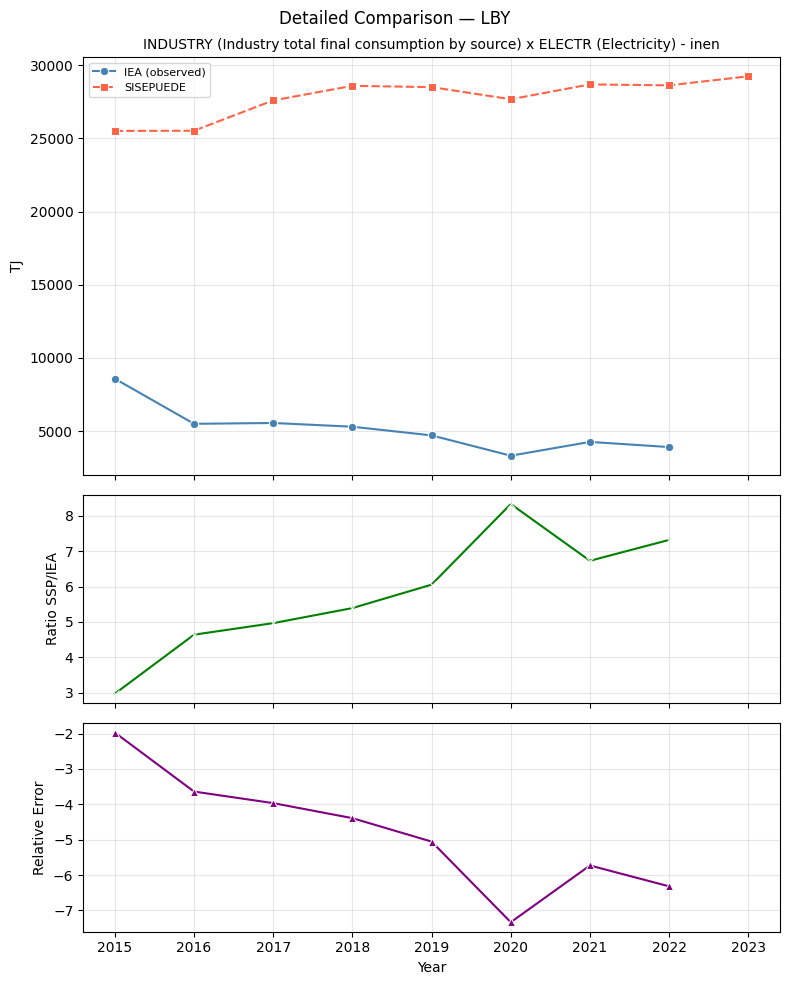

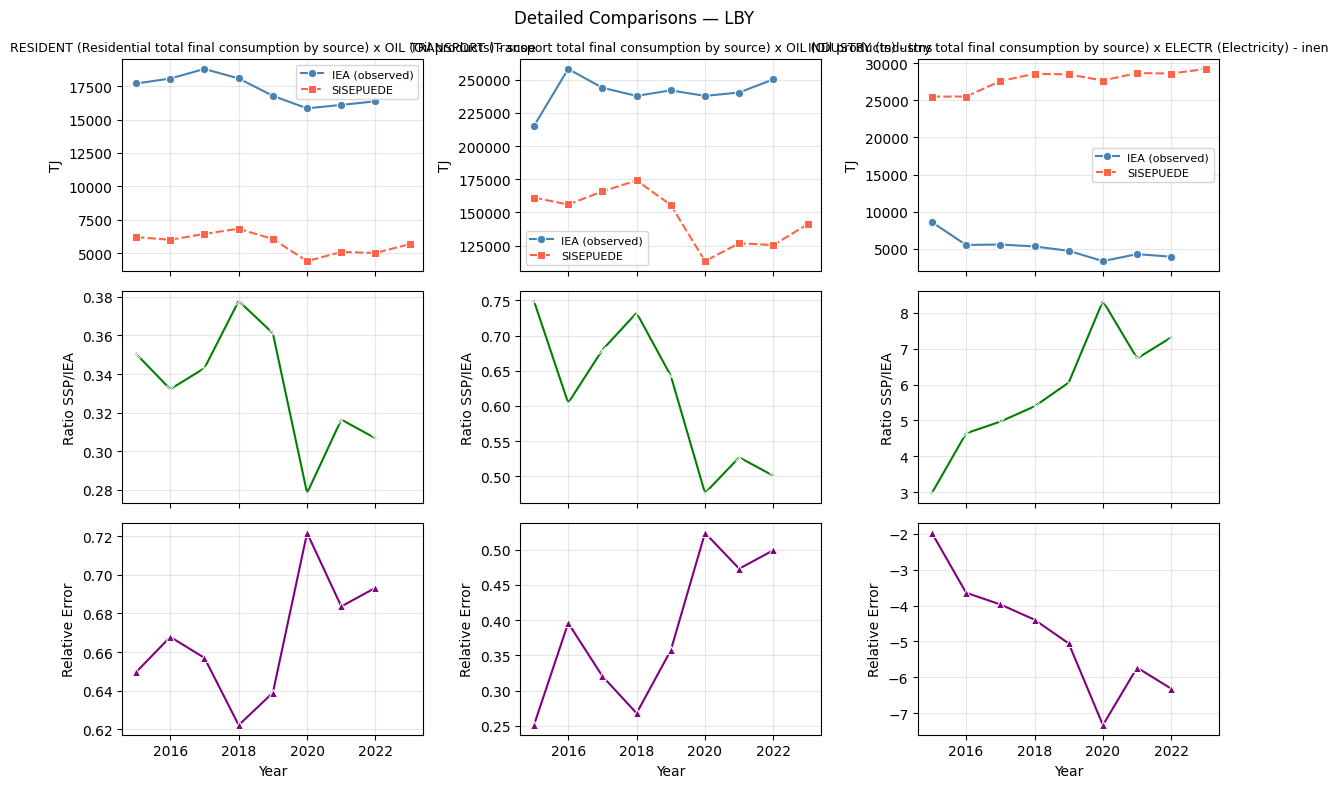

In [13]:
import importlib
import sisepuede.utilities._plotting
importlib.reload(sisepuede.utilities._plotting)
from sisepuede.utilities._plotting_seaborn import plot_detailed_comparisons, plot_selected_comparisons, plot_metric_bar
# from sisepuede.utilities._plotting import plot_detailed_comparisons, plot_selected_comparisons, plot_metric_bar

plot_condition = (df_comparison['year'] >= START_YEAR) & (df_comparison['year'] <= TRUE_DATA_LIMIT_YEAR)
df_comparison = df_comparison.loc[plot_condition]

# Detailed comparison for a single pair
plot_detailed_comparisons(
    df_comparison,
    pairs=('INDUSTRY', 'ELECTR'),
    second_var='ratio_sisepuede_over_iea',
    third_var='rel_err_iea',
    second_label='Ratio SSP/IEA',
    third_label='Relative Error',
    country=ISO_COUNTRY,
)

# Detailed comparison for a multiple pairs
plot_detailed_comparisons(
    df_comparison,
    pairs=[('RESIDENT', 'OIL'), ('TRANSPORT', 'OIL'), ('INDUSTRY', 'ELECTR')],
    second_var='ratio_sisepuede_over_iea',
    third_var='rel_err_iea',
    second_label='Ratio SSP/IEA',
    third_label='Relative Error',
    country=ISO_COUNTRY,
)

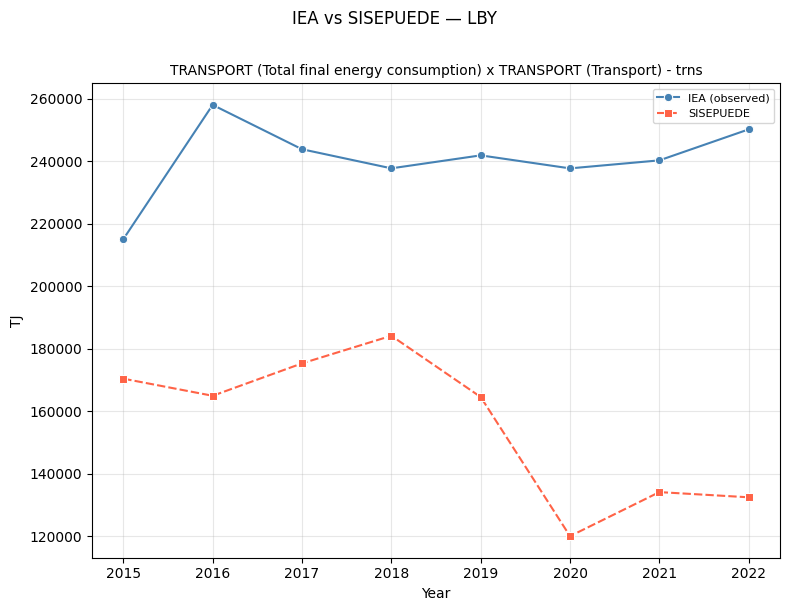

In [14]:
# Single plot: plot one pair
plot_selected_comparisons(
    df_comparison,
    [("TRANSPORT", "TRANSPORT")],
    country=ISO_COUNTRY,
)

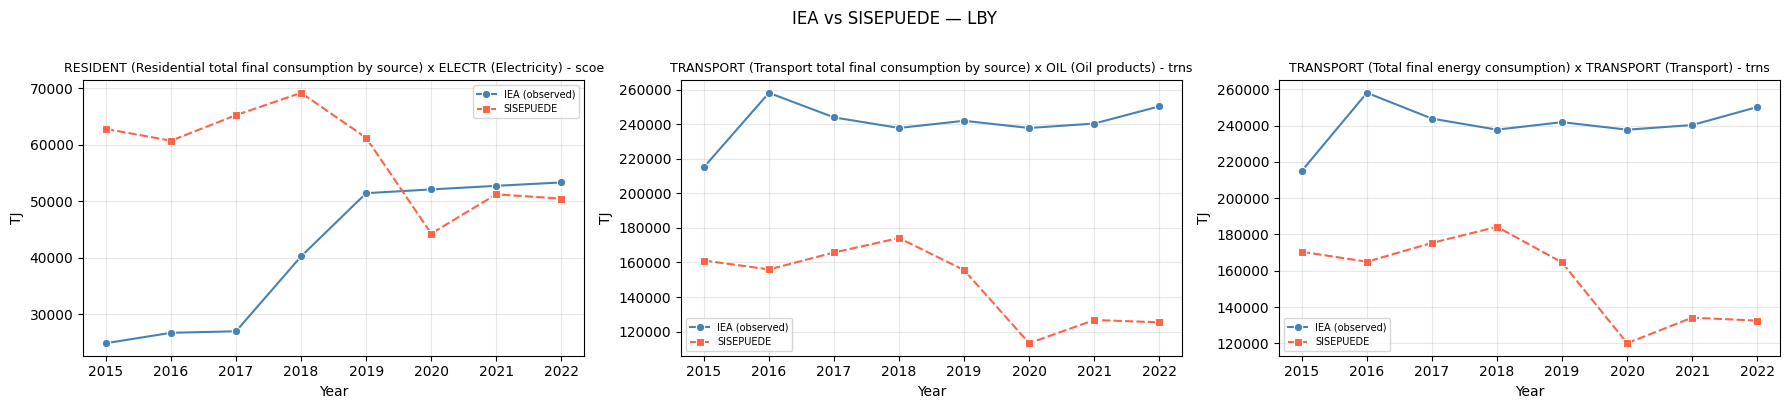

In [15]:
# Multiple panels: plot several pairs in separate panels
plot_selected_comparisons(
    df_comparison,
    [("RESIDENT", "ELECTR"), ("TRANSPORT", "OIL"), ("TRANSPORT", "TRANSPORT")],
    country=ISO_COUNTRY,
)

---
## 8.2 Bar Plot of Metrics

Plot a bar chart showing differences, ratios, or relative errors between SSP and IEA values for a specific year. 
Note the _mapping quality_ (between parenthesis); this should inform how much importance we give to adjusting for that target.

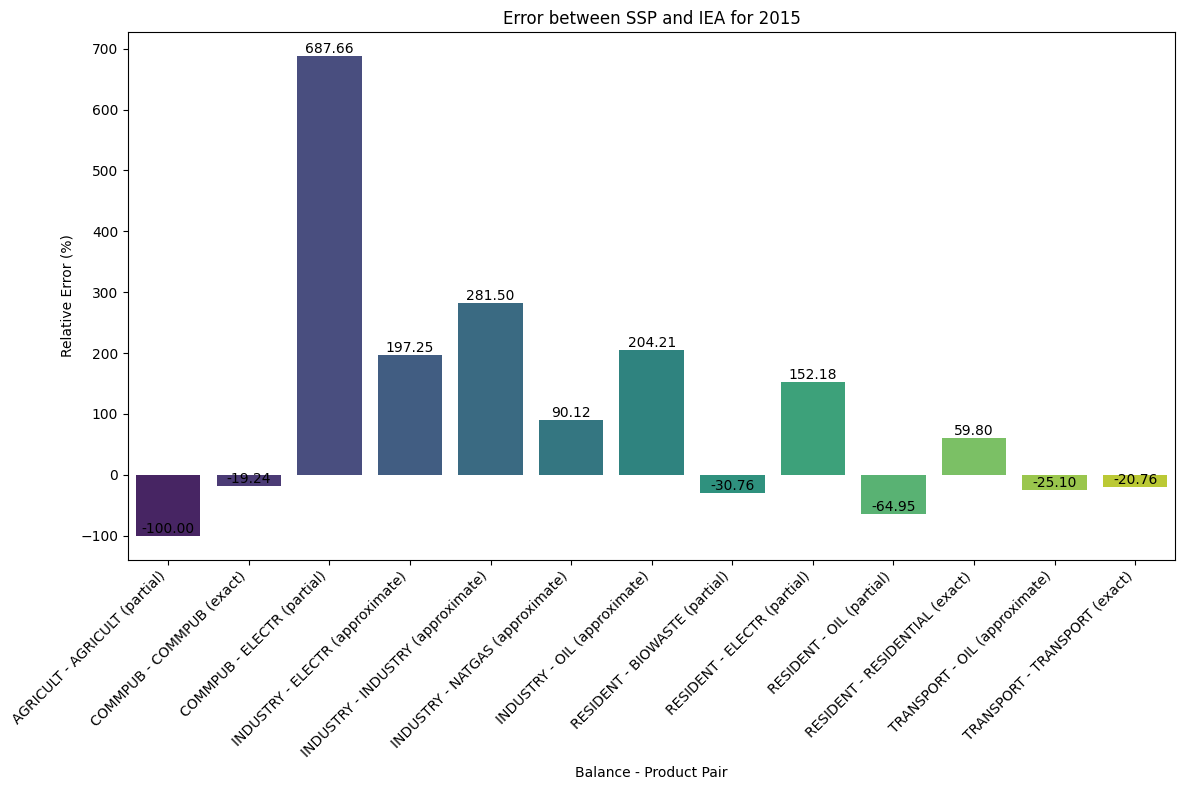

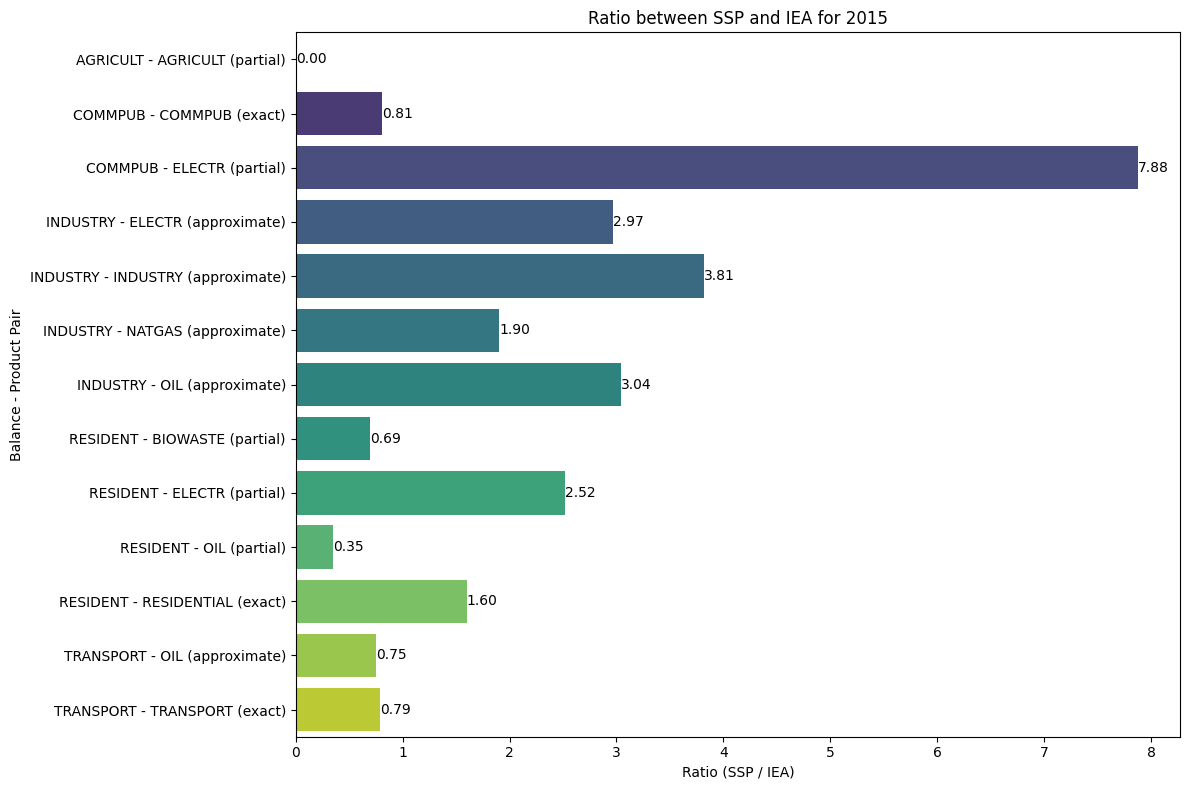

In [16]:
# Example: Vertical bar plot of relative errors for YYYY
plot_metric_bar(
    df_comparison,
    year=2015,
    metric='error',
    orientation='vertical'
)

# Example: Horizontal bar plot of ratios for YYYY
plot_metric_bar(
    df_comparison,
    year=2015,
    metric='ratio',
    orientation='horizontal'
)

#### NOTE TO SELF:
Relative error will break down when IEA is zero or near-zero. Dividing by a very small number produces enormous relative errors that aren't meaningful. This will happen for fuels that a country barely uses. 
We'll want to flag or exclude those cases rather than let them dominate the diagnostics, or apply a small threshold below which you ignore the relative error and fall back to absolute difference.


---
## 9. Export

In [17]:
PATH_OUTPUT = f"/Users/dianamendez/Documents/sisepuede/iea_vs_sisepuede_{ISO_COUNTRY}.csv"

df_comparison.to_csv(PATH_OUTPUT, index=False)
print(f"Saved to {PATH_OUTPUT}")

Saved to /Users/dianamendez/Documents/sisepuede/iea_vs_sisepuede_LBY.csv
